In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline

from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

from sklearn.model_selection import RandomizedSearchCV

from sklearn.decomposition import PCA

import pickle

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
with open("/kaggle/input/tokens/tokens.pkl", "rb") as f:
    data = pickle.load(f)

print(data["headlines_tokens"][:10])   
print(data["categories"][:5])          

['family', 'generation', 'changer', 'firestorm', 'aol', 'employee', 'benefit', 'cut', 'dakota', 'access']
['IMPACT', 'BUSINESS', 'POLITICS', 'GREEN', 'SCIENCE']


In [4]:
print(type(data))
print(data.keys())

<class 'dict'>
dict_keys(['headlines_tokens', 'description_tokens', 'categories'])


## Bag of Word Implementation

In [5]:
docs = [
    " ".join(data["headlines_tokens"]),
    " ".join(data["description_tokens"])
]

In [6]:
type(data["headlines_tokens"])

list

In [7]:
vectorizer = CountVectorizer()
model_bow = vectorizer.fit_transform(docs)

In [8]:
from itertools import islice

print("Vocabulary:", dict(islice(vectorizer.vocabulary_.items(), 5)))
print("Feature Names:", vectorizer.get_feature_names_out()[:5])
print("Bag of Words Representation:\n", model_bow.toarray()[:5, :5])

Vocabulary: {'family': 6915, 'generation': 7867, 'changer': 3472, 'firestorm': 7216, 'aol': 1364}
Feature Names: ['0000' '002' '007' '01042013' '05152013']
Bag of Words Representation:
 [[0 1 1 0 0]
 [1 0 0 1 1]]


In [9]:
word_counts = np.sum(model_bow.toarray(), axis=0)
words = vectorizer.get_feature_names_out()
df = pd.DataFrame({"words": words, "frequency": word_counts, })

top10_df = df.sort_values(by="frequency", ascending=False).head(10)

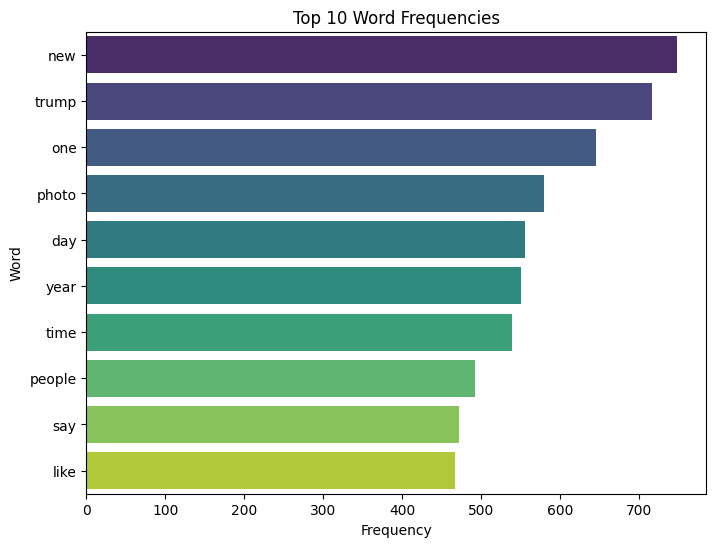

In [10]:
plt.figure(figsize=(8,6))
sns.barplot(x="frequency", y="words", data=top10_df, palette="viridis")

plt.title("Top 10 Word Frequencies")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()

## Model Implementation

In [11]:
# join descriptions per each article
def combine(data):
    articles = []
    for headline_tokens, desc_tokens in zip(data["headlines_tokens"], data["description_tokens"]):

        headline = " ".join(headline_tokens.split())
        description = " ".join(desc_tokens.split())

        articles.append(headline + " " + description)
    return articles


In [12]:
articles = combine(data)
print(type(articles)) 

<class 'list'>


In [13]:
print(len(articles))                 
print(articles[0])          # combined document

54275
family wont


### Baseline Model (TF-IDF + SVD + KMeans)

In [14]:
pipeline_baseline = Pipeline([
    ('tfidf', TfidfVectorizer(
        lowercase=True, 
        stop_words="english", 
        ngram_range=(1,2), 
        max_df=0.5, 
        min_df=5, 
        max_features=10000)),
    ('svd', TruncatedSVD(n_components=100, random_state=22)),
    ('kmeans', KMeans(n_clusters=20, random_state=22))
])

In [15]:
pipeline_baseline.fit(articles)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.5, max_features=10000, min_df=5,
                                 ngram_range=(1, 2), stop_words='english')),
                ('svd', TruncatedSVD(n_components=100, random_state=22)),
                ('kmeans', KMeans(n_clusters=20, random_state=22))])

In [16]:
labels = pipeline_baseline.predict(articles[:20]) 
print (labels)

[ 0  0 14  0  0  0  0  7  0 14  0  0  0  0  0  0  0  0  0  0]


In [17]:
# get cluster labels
labels_baseline = pipeline_baseline.named_steps['kmeans'].labels_  

In [18]:
# get features
X_reduced_tfidf = pipeline_baseline.named_steps['svd'].transform( pipeline_baseline.named_steps['tfidf'].transform(articles) )

In [19]:
print("Silhouette:", silhouette_score(X_reduced_tfidf, labels_baseline)) 
print("Calinski-Harabasz:", calinski_harabasz_score(X_reduced_tfidf, labels_baseline))
print("Davies–Bouldin Index:", davies_bouldin_score(X_reduced_tfidf, labels_baseline))

Silhouette: 0.5544079748858225
Calinski-Harabasz: 1227.8056266138587
Davies–Bouldin Index: 0.643118780630899


### Hyperparameter Tuning for Baseline Model

In [20]:
param_grid = { 'tfidf__ngram_range': [(1,1), (1,2)], 
              'tfidf__max_features': [5000, 10000, 20000], 
              'tfidf__max_df': [0.1, 0.25],
              'svd__n_components': [50, 100, 150, 200],
              'kmeans__n_clusters': [15,20, 25, 27, 30]}

In [21]:
random_search = RandomizedSearchCV(
    pipeline_baseline,
    param_distributions=param_grid,
    n_iter=20,
    n_jobs=-1,
    random_state=42
)

In [22]:
random_search.fit(articles) 
print("Best parameters:", random_search.best_params_)

Best parameters: {'tfidf__ngram_range': (1, 1), 'tfidf__max_features': 10000, 'tfidf__max_df': 0.25, 'svd__n_components': 50, 'kmeans__n_clusters': 27}


### Tuned Model

In [23]:
pipeline_tuned = Pipeline([
    ('tfidf', TfidfVectorizer(
        lowercase=True, 
        stop_words="english", 
        ngram_range=(1,1), 
        max_df=0.25, 
        min_df=5, 
        max_features=10000)),
    ('svd', TruncatedSVD(n_components=50, random_state=22)),
    ('kmeans', KMeans(n_clusters=27, random_state=22))
])

In [24]:
pipeline_tuned.fit(articles)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.25, max_features=10000, min_df=5,
                                 stop_words='english')),
                ('svd', TruncatedSVD(n_components=50, random_state=22)),
                ('kmeans', KMeans(n_clusters=27, random_state=22))])

In [25]:
labels = pipeline_tuned.predict(articles[:20]) 
print (labels)

[ 0  0  5  0  0  0  0 25  0  5  0  0  0  0  0  0 20  0  0  0]


In [26]:
# get cluster labels
labels_tuned_2 = pipeline_tuned.named_steps['kmeans'].labels_  

# get features
X_reduced_tfidf_2 = pipeline_tuned.named_steps['svd'].transform( pipeline_tuned.named_steps['tfidf'].transform(articles) )

In [27]:
print("Silhouette_tuned:", silhouette_score(X_reduced_tfidf_2, labels_tuned_2)) 
print("Calinski-Harabasz_tuned:", calinski_harabasz_score(X_reduced_tfidf_2, labels_tuned_2))
print("Davies–Bouldin Index_tuned:", davies_bouldin_score(X_reduced_tfidf_2, labels_tuned_2))

Silhouette_tuned: 0.7832403085110482
Calinski-Harabasz_tuned: 2979.1682835005035
Davies–Bouldin Index_tuned: 0.47069316929595323


## Model Comparison

In [28]:
data = {
    "Metric": ["Silhouette Score", "Calinski-Harabasz", "Davies–Bouldin Index"],
    "Baseline": [0.55440797, 1227.805626, 0.64311878],
    "Tuned": [0.78324031, 2979.168284, 0.47069317],
}
metrics_df = pd.DataFrame(data)
print("### Model Performance Comparison ###")
print(metrics_df.to_string(index=False))

### Model Performance Comparison ###
              Metric    Baseline       Tuned
    Silhouette Score    0.554408    0.783240
   Calinski-Harabasz 1227.805626 2979.168284
Davies–Bouldin Index    0.643119    0.470693


## Visualization using PCA

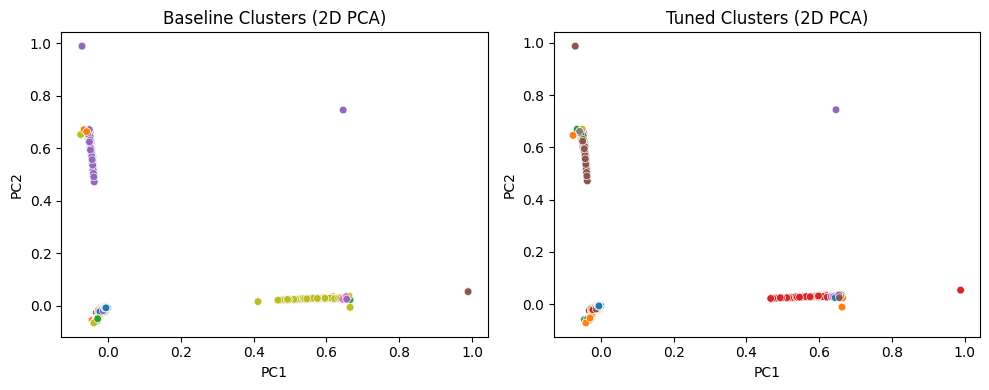

In [29]:
def get_cluster_data(pipeline, X):
    pipeline.fit(X)
    labels = pipeline.named_steps['kmeans'].labels_
    X_reduced = pipeline.named_steps['svd'].transform(
        pipeline.named_steps['tfidf'].transform(X)
    )
    pca = PCA(n_components=2, random_state=22)
    X_2d = pca.fit_transform(X_reduced)
    return pd.DataFrame({"PC1": X_2d[:,0], "PC2": X_2d[:,1], "Cluster": labels})

# Prepare data for both pipelines
baseline_df = get_cluster_data(pipeline_baseline, articles)
tuned_df = get_cluster_data(pipeline_tuned, articles)

# Side-by-side plots (smaller size)
fig, axes = plt.subplots(1, 2, figsize=(10,4))  # smaller figure
sns.scatterplot(data=baseline_df, x="PC1", y="PC2", hue="Cluster",
                palette="tab10", s=30, ax=axes[0], legend=False)
axes[0].set_title("Baseline Clusters (2D PCA)")

sns.scatterplot(data=tuned_df, x="PC1", y="PC2", hue="Cluster",
                palette="tab10", s=30, ax=axes[1], legend=False)
axes[1].set_title("Tuned Clusters (2D PCA)")

plt.tight_layout()
plt.savefig("clusters_comparison.png", dpi=300)
plt.show()


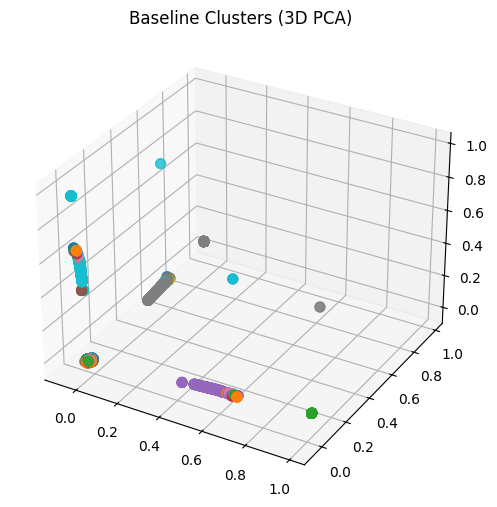

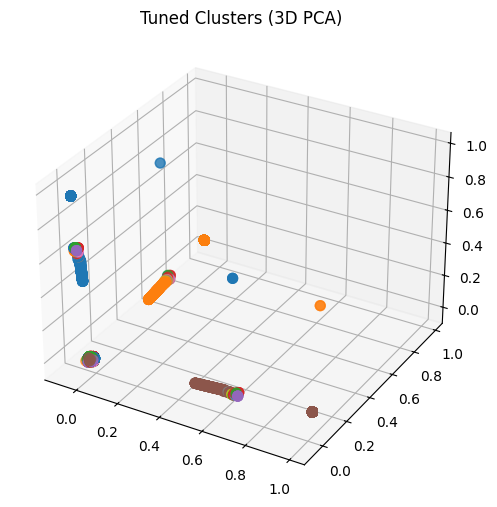

In [30]:
def plot_clusters_3d(pipeline, X, title):
    # Fit pipeline
    pipeline.fit(X)
    labels = pipeline.named_steps['kmeans'].labels_
    X_reduced = pipeline.named_steps['svd'].transform(
        pipeline.named_steps['tfidf'].transform(X)
    )
    
    # Reduce to 3D with PCA
    pca = PCA(n_components=3, random_state=22)
    X_3d = pca.fit_transform(X_reduced)
    
    # Plot in 3D
    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(X_3d[:,0], X_3d[:,1], X_3d[:,2],
                         c=labels, cmap="tab10", s=50)
    ax.set_title(title)
    plt.show()

plot_clusters_3d(pipeline_baseline, articles, "Baseline Clusters (3D PCA)")
plot_clusters_3d(pipeline_tuned, articles, "Tuned Clusters (3D PCA)")


## Cluster Vocabulary Check

In [31]:
tfidf = pipeline_tuned.named_steps['tfidf']
terms = tfidf.get_feature_names_out()

In [32]:
# Get KMeans cluster centers in reduced space
centroids = pipeline_tuned.named_steps['kmeans'].cluster_centers_

# Map back to original TF-IDF space
original_space_centroids = np.dot(centroids, pipeline_tuned.named_steps['svd'].components_)

# For each cluster, get top terms
n_top_terms = 10
for i, centroid in enumerate(original_space_centroids):
    top_indices = centroid.argsort()[-n_top_terms:][::-1]
    top_terms = [terms[ind] for ind in top_indices]
    print(f"Cluster {i}: {', '.join(top_terms)}")


Cluster 0: work, thing, white, donald, help, need, child, right, big, american
Cluster 1: photo, need, united, star, im, feel, work, right, kid, donald
Cluster 2: day, photo, donald, new, country, man, got, national, star, climate
Cluster 3: say, people, american, let, im, style, big, question, hope, rule
Cluster 4: new, trump, food, month, season, mother, fact, healthy, research, killed
Cluster 5: new, state, home, fact, think, change, thing, better, watch, month
Cluster 6: video, like, gop, going, dream, benefit, child, kid, great, enjoy
Cluster 7: year, photo, question, house, man, art, thats, wont, film, social
Cluster 8: people, photo, new, trump, donald, day, america, watch, death, good
Cluster 9: woman, photo, great, sander, impact, new, huffpost, million, feel, study
Cluster 10: world, thing, woman, fashion, work, future, say, time, head, spot
Cluster 11: time, trump, day, photo, going, huffpost, climate, use, campaign, marriage
Cluster 12: dont, ryan, great, fashion, big, feel

## Cluster Distribution Check

Cluster Size Distribution
 Cluster  Headline Count
       0           46502
       1             505
       2             407
       3             371
       4               3
       5             546
       6             267
       7             359
       8             343
       9             295
      10             274
      11             365
      12             218
      13             594
      14             308
      15             339
      16             207
      17             321
      18             243
      19             168
      20             232
      21             233
      22             205
      23             182
      24             229
      25             314
      26             245


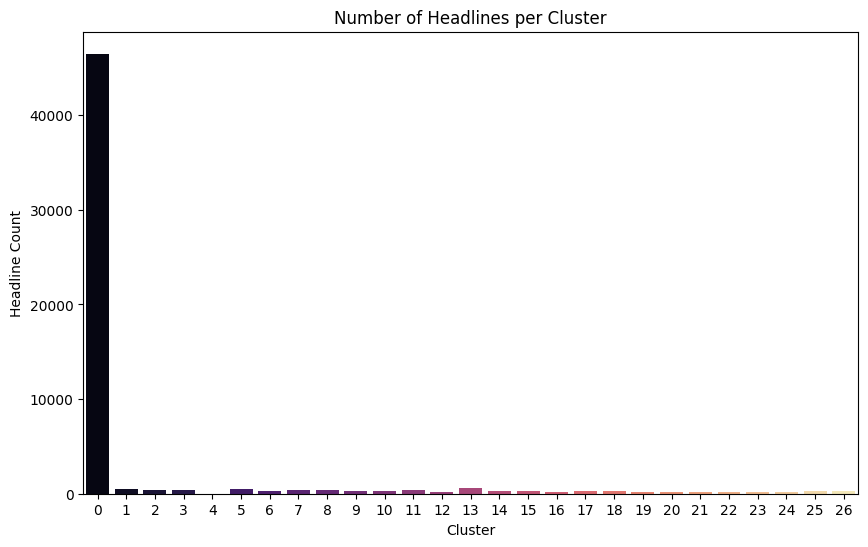

In [33]:

def check_cluster_distribution(labels):
    counts = pd.Series(labels).value_counts().sort_index()
    counts_df = pd.DataFrame({'Cluster': counts.index, 'Headline Count': counts.values})
    
    # Display the table
    print("Cluster Size Distribution")
    print(counts_df.to_string(index=False))
    
    # Plot the distribution
    plt.figure(figsize=(10, 6))
    sns.barplot(data=counts_df, x='Cluster', y='Headline Count', palette='magma')
    plt.title("Number of Headlines per Cluster")
    plt.show()

distribution = pipeline_tuned.named_steps['kmeans'].labels_
check_cluster_distribution(distribution)